## Ejercicio 3 - Análisis de Depreciación y Valor de Mercado

Para este ejercicio vamos a emplear los siguientes datos https://www.kaggle.com/datasets/swatikhedekar/eda-on-car-sales-dataset-in-ukraine/data

Este conjunto de datos contiene información sobre más de 9500 ventas de automóviles en Ucrania. La mayoría de ellos son automóviles usados, lo que abre la posibilidad de analizar características relacionadas con el funcionamiento de los automóviles. Se trata de un subconjunto de todos los datos sobre automóviles en Ucrania, y con él analizaremos los distintos parámetros de las ventas.

## Información de las variables

* car: marca.
* price: precio de compra.
* body: tipo de vehículo.
* mileage: kilometraje en miles de kilómetros.
* engV: cilindrada del motor.
* engType: tipo de combustible. 
* registration: indica si el coche está registrado en Ucrania ("yes") o si es importado("no")
* year: año de registro.
* model: modelo de coche.
* drive: tipo de tracción.

## Análisis

### 1.- Carga el dataset de ventas de coches, muestra las dimensiones y el tipo de cada variable.

In [1]:
import pandas as pd

df=pd.read_csv("Car_Sales.csv", sep=";")

df.head()

,car,price,body,mileage,engV,engType,registration,year,model,drive
0,Ford,15500,crossover,68,"2,5",Gas,yes,2010,Kuga,full
1,Mercedes-Benz,20500,sedan,173,"1,8",Gas,yes,2011,E-Class,rear
2,Mercedes-Benz,35000,other,135,"5,5",Petrol,yes,2008,CL 550,rear
3,Mercedes-Benz,17800,van,162,"1,8",Diesel,yes,2012,B 180,front
4,Mercedes-Benz,33000,vagon,91,NaN,Other,yes,2013,E-Class,NaN


In [2]:
print("La dimensión del dataframe es de ", df.shape)

La dimensión del dataframe es de  (9576, 10)


In [3]:
print("Los tipos de variables que componen nuestro df son: ")
df.info()

Los tipos de variables que componen nuestro df son: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9576 entries, 0 to 9575
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   car           9576 non-null   object
 1   price         9576 non-null   object
 2   body          9576 non-null   object
 3   mileage       9576 non-null   int64 
 4   engV          9142 non-null   object
 5   engType       9576 non-null   object
 6   registration  9576 non-null   object
 7   year          9576 non-null   int64 
 8   model         9576 non-null   object
 9   drive         9065 non-null   object
dtypes: int64(2), object(8)
memory usage: 748.3+ KB


In [ ]:
# He visto que los separadores de "price" y engV" son una ','. Debo cambiarlo por un '.' para evitar errores en el futuro análisis

df["price"] = df["price"].astype(str).str.replace(",", ".")
df["engV"] = df["engV"].astype(str).str.replace(",", ".")

In [ ]:
# He decidido modificar el tipo de las variables "price" y "engV" ya que corresponden a variables númericas en lugar de objetos

df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["engV"] = pd.to_numeric(df["engV"], errors="coerce")

In [6]:
print("Los tipos de variables que componen nuestro df son: ")
df.info()

Los tipos de variables que componen nuestro df son: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9576 entries, 0 to 9575
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   car           9576 non-null   object 
 1   price         9576 non-null   float64
 2   body          9576 non-null   object 
 3   mileage       9576 non-null   int64  
 4   engV          9142 non-null   float64
 5   engType       9576 non-null   object 
 6   registration  9576 non-null   object 
 7   year          9576 non-null   int64  
 8   model         9576 non-null   object 
 9   drive         9065 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 748.3+ KB


### 2.- Analizar la variable "price" y la distribución de sus valores identificando valores extremos que distorsionan la media y explica la regla que has usado para solucionarlo. Compara las medias y las medianas

In [7]:
# Analizo los valores de la columna "price" porque posee valores muy dispersos que van a distorsionar los cálculos 
df["price"].describe()

count      9576.000000
mean      15633.317316
std       24106.523436
min           0.000000
25%        4999.000000
50%        9200.000000
75%       16700.000000
max      547800.000000
Name: price, dtype: float64

Como se puede observar en el 'describe' los datos de price están muy dispersos. Al analizar los datos gráficamente, se pueden ver muchos coches con un precio menor de 500€€ y muchos coches con un precio poe encima de los 150000€. 

Text(0, 0.5, 'Cantidad de Coches')

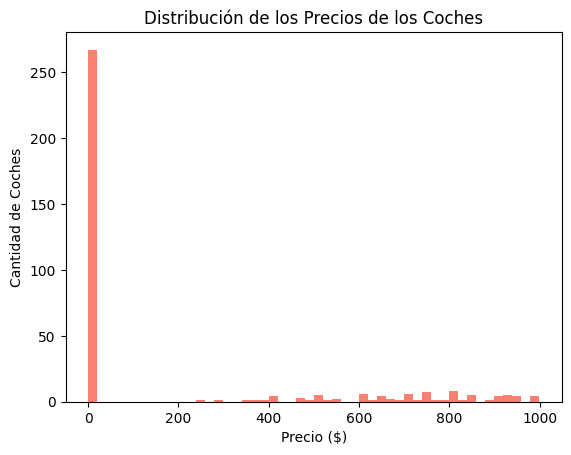

In [ ]:
import matplotlib.pyplot as plt

low_prices= df[df["price"]<1000]["price"]

plt.hist(low_prices, bins=50, color="salmon")

plt.title("Distribución de los Precios de los Coches")
plt.xlabel("Precio ($)")
plt.ylabel("Cantidad de Coches")

Analizando los coches con precio 0, se observa que la mayoría de los coches han sido compraados en el mismo año en el que el estudio ha sido realizado, por lo que se puede intuir que los coches son NUEVOS (24,34%). 
Por otra parte, existe una parte de los datos que tienen precio 0 y que corresponden a otro año, esto puede ser debido a errores en la inputación de los datos, preferencia del vendedor sobre el precio para mantenerlo como "precio a consultar" o simplemente que no se disponía de la información del precio en el momento en que los datos fueron recogidos.

In [9]:
cars_price0 = df[df["price"] == 0]
total_cars_price0 = len(cars_price0)
new_cars= len(cars_price0[cars_price0["year"]==2016])
percentage = round(((new_cars/total_cars_price0)*100),2)

print(f"El porcentaje de coches nuevos frente a los coches que tenemos con precio 0 es de {percentage} %")

El porcentaje de coches nuevos frente a los coches que tenemos con precio 0 es de 24.34 %


Por otra parte, existen muchos coches que tienen un precio menos de 500€. Estos datos pueden corresponder a precios simbólicos, precios gancho, pagos parciales del los vehículos o simplemente, de nuevo, errores en la carga de datos. 

Incluir valores iguales a cero o inferiores a 500€ en el análisis daría una imagen falsa sobre los datos. He decidido transformar estos valores en NaN para garantizar que los cálculos estadísticos reflejen la realidad del mercado sin sesgos, para poder así conservar el resto de la información del vehículo (como marca o kilometraje) para un análisis íntegro en el resto de los apartados.

Además de los precios que se encuentran por debajo de 500€, existen precios desorbitados que ascienten hasta los 600000€ aproximadamente. por la misma razón que se han descartado los precios por debajo de los 500€, vamos a convertir en nulos los precios que se encuentran por encima de los 150000€ para poder hacer estimaciones correctas

Text(0, 0.5, 'Cantidad de Coches')

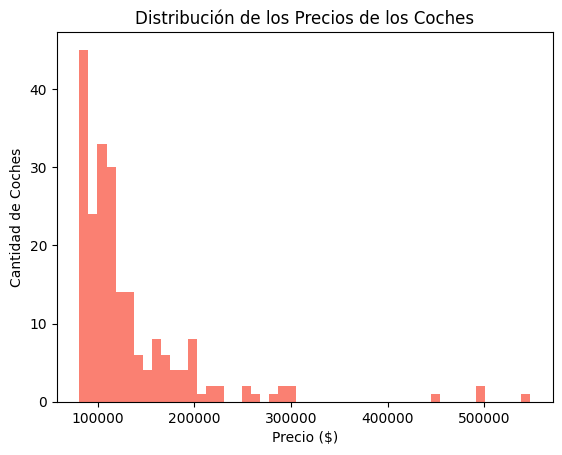

In [ ]:
high_prices= df[df["price"]>80000]["price"]

plt.hist(high_prices, bins=50, color="salmon")

plt.title("Distribución de los Precios de los Coches")
plt.xlabel("Precio ($)")
plt.ylabel("Cantidad de Coches")

In [11]:
# Valores previos al cambio
price_nulls_b4_filter = df["price"].isnull().sum()
mean_price_not_filtered = round((df["price"].mean()),2)
median_price_b4_filter = round((df["price"].median()),2)

print(f"El número de valores nulos que incluyes 'price' antes del cambio es de {price_nulls_b4_filter}.\nEl valor de la media antes de realizar el filto es de {mean_price_not_filtered}. \nEl valor de la mediana antes de realizar el filto es de {median_price_b4_filter}")

El número de valores nulos que incluyes 'price' antes del cambio es de 0.
El valor de la media antes de realizar el filto es de 15633.32. 
El valor de la mediana antes de realizar el filto es de 9200.0


In [12]:
# Valores posteriores al cambio
df["price"] = df["price"].mask((df["price"] < 500) | (df["price"] > 150000))

price_nulls = df["price"].isnull().sum()
mean_price = round((df["price"].mean()),2)
median_price = round((df["price"].median()),2)

print(f"El número de valores nulos que incluyes 'price' antes del cambio es de {price_nulls}.\nEl valor de la media antes de realizar el filto es de {mean_price}. \nEl valor de la media antes de realizar el filto es de {median_price}")


El número de valores nulos que incluyes 'price' antes del cambio es de 330.
El valor de la media antes de realizar el filto es de 14986.01. 
El valor de la media antes de realizar el filto es de 9500.0


Como podemos observar, al hacer este filtro la media y la mediana han reducido su distancia. Para llegar a esto hemos convertido en nulos los datos que provocaban el sesgo, evitando el problema que generaban en las métricas de 'price' pero, manteniendo el resto de características de esas líneas para realizar próximos cálculos.

### 3.- Revisa la columna de engV y trata como nulos los valores que no sean coherentes. Revisa después los datos que poseen valores nulos en la columna de 'price' y 'engV' y elimínalos.

In [13]:
df["engV"].isnull().sum() 

np.int64(434)

In [14]:
df["engV"].describe()

count    9142.000000
mean        2.646344
std         5.927699
min         0.100000
25%         1.600000
50%         2.000000
75%         2.500000
max        99.990000
Name: engV, dtype: float64

Text(0, 0.5, 'Cantidad de Coches')

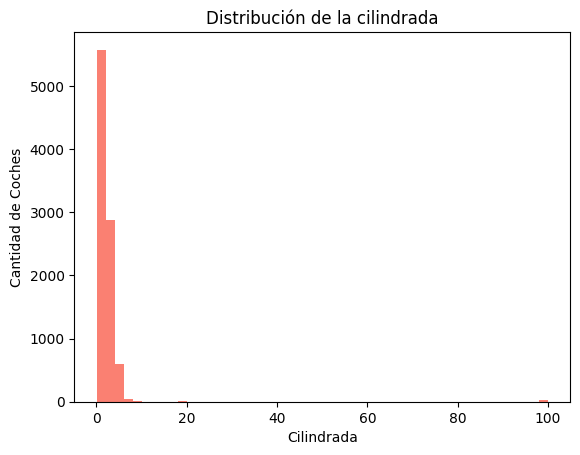

In [ ]:
plt.hist(df["engV"], bins=50, color="salmon")

plt.title("Distribución de la cilindrada")
plt.xlabel("Cilindrada")
plt.ylabel("Cantidad de Coches")

La variable engV representa la cilindrada del motor en litros, en el análisis exploratorio se detectaron valores incoherentes (como motores de 99L), por lo que se procedió a filtrar el dataset para mantener únicamente vehículos con una cilindrada entre 0.5L y 7L, asegurando así la fiabilidad de las comparaciones de precios.

Text(0, 0.5, 'Cantidad de Coches')

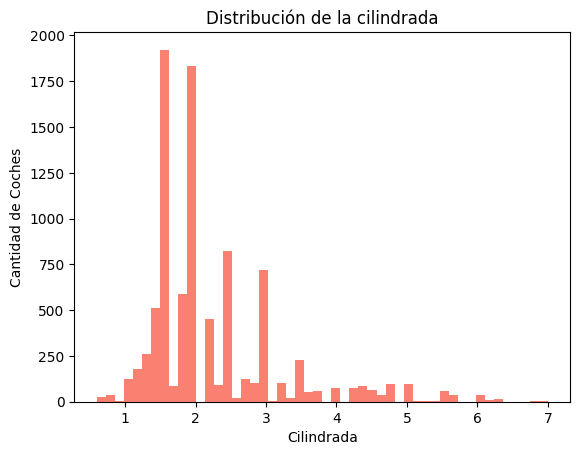

In [ ]:
df["engV"] = df["engV"].mask((df["engV"] < 0.5) | (df["engV"] > 7))

plt.hist(df["engV"], bins=50, color="salmon")

plt.title("Distribución de la cilindrada")
plt.xlabel("Cilindrada")
plt.ylabel("Cantidad de Coches")

In [17]:
# Compruebo que filas tienen un valor nulo en las columnas de 'price' y 'engV' y las elimino. 
# Creo también unas métricas para ver el impacto que tiene eliminar las filas con nulos. 

dim_before = df.shape
print(f"La dimensión del df antes de eliminar los datos era de {dim_before}")

La dimensión del df antes de eliminar los datos era de (9576, 10)


In [ ]:
null_lines = df[df["price"].isnull() & df["engV"].isnull()]

print(f"Se han encontrado {len(null_lines)} filas con valores nulos en 'price' y 'engV'.")
null_lines.head()

Se han encontrado 20 filas con valores nulos en 'price' y 'engV'.


,car,price,body,mileage,engV,engType,registration,year,model,drive
240,Tesla,NaN,sedan,0,NaN,Other,yes,2016,Model S,full
427,Tesla,NaN,sedan,7,NaN,Other,yes,2016,Model S,rear
1116,Renault,NaN,van,192,NaN,Diesel,yes,2011,Kangoo ����.,front
1437,Tesla,NaN,crossover,0,NaN,Other,yes,2016,Model X,full
2486,Tesla,NaN,crossover,1,NaN,Other,yes,2016,Model X,full


In [19]:
df = df.drop(index=null_lines.index)

dim_after = df.shape
print(f"La dimensión del df después de eliminar los datos es de {dim_after}")


La dimensión del df después de eliminar los datos es de (9556, 10)


### 4.- Crea una nueva columna llamada Years_Old calculando la diferencia entre el año actual (2026) y la columna year.

In [20]:
df["years_old"] = 2026 - df["year"] 
df.head()

,car,price,body,mileage,engV,engType,registration,year,model,drive,years_old
0,Ford,15500.0,crossover,68,2.5,Gas,yes,2010,Kuga,full,16
1,Mercedes-Benz,20500.0,sedan,173,1.8,Gas,yes,2011,E-Class,rear,15
2,Mercedes-Benz,35000.0,other,135,5.5,Petrol,yes,2008,CL 550,rear,18
3,Mercedes-Benz,17800.0,van,162,1.8,Diesel,yes,2012,B 180,front,14
4,Mercedes-Benz,33000.0,vagon,91,NaN,Other,yes,2013,E-Class,NaN,13


### 5.- Crea una columna llamada Usage_Level a partir de la de mileage con las siguientes calificaciones: "Low"-> Kilometraje < 50.000, "Medium"-> 50.000 a 150.000, "High"-> 150.000

Tras analizar de cerca los valores que se incluyen en la columna de 'mileage' he visto que hay muchos coches con kilometraje 0 y que han sido registrados muchos años atrás. Para evitar cálculos sesgados, voy a convertir en nulos todos aquellos coches que poseen 0km y no fueron registrados en el 2026, para posteriormente eliminarlos. 

In [22]:
df["mileage"] = df["mileage"].mask((df["mileage"] == 0) & (df["year"] != 2016))
df["mileage"].isnull().sum()

np.int64(54)

In [24]:
df = df.dropna(subset=["mileage"])
print("La dimensión del df después de eliminar los datos es de ", df.shape)

La dimensión del df después de eliminar los datos es de  (9502, 11)


Para realizar las clasificaciones de la columna usaremos numpy

In [25]:
import numpy as np

In [28]:
condiciones = [(df["mileage"] < 50),(df["mileage"] >= 50) & (df["mileage"] <= 150),(df["mileage"] > 150)]
valores = ["Low", "Medium", "High"]

df["usage_level"] = np.select(condiciones, valores, default="NaN")
df.head()

,car,price,body,mileage,engV,engType,registration,year,model,drive,years_old,usage_level
0,Ford,15500.0,crossover,68.0,2.5,Gas,yes,2010,Kuga,full,16,Medium
1,Mercedes-Benz,20500.0,sedan,173.0,1.8,Gas,yes,2011,E-Class,rear,15,High
2,Mercedes-Benz,35000.0,other,135.0,5.5,Petrol,yes,2008,CL 550,rear,18,Medium
3,Mercedes-Benz,17800.0,van,162.0,1.8,Diesel,yes,2012,B 180,front,14,High
4,Mercedes-Benz,33000.0,vagon,91.0,NaN,Other,yes,2013,E-Class,NaN,13,Medium


### 6.- Realiza un gráfico de dispersión para ver cómo influye el kilometraje en el precio.

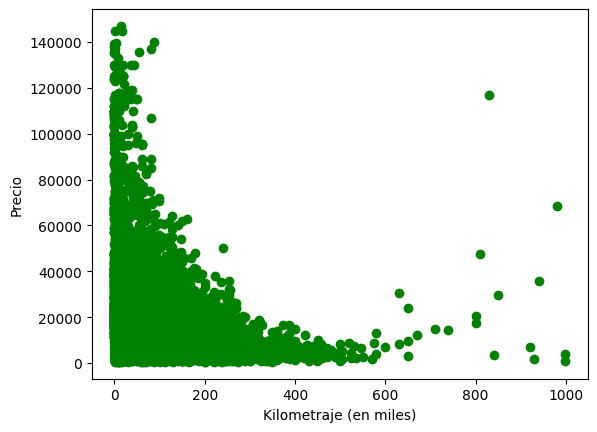

In [32]:
plt.scatter(df["mileage"], df["price"], color="g")

plt.xlabel("Kilometraje (en miles)")
plt.ylabel("Precio")
plt.show()

Como se puede observar, las variables kilometraje y precio poseen una correlación negativa, lo que significa que a medida que el kilometraje aumenta, el precio va a disminuir. En la parte izquierda del gráfico se puede interpretar que los coches pierden mucha más proporción de su valor en sus primeros miles de kilómetros que cuando ya son viejos. Y segñun vamos avanzando en el gráfico podemos ver que el precio de los coches se estabiliza hasta mantener un precio residual bajo 

### 7.- Calcula el precio medio según el tipo de tracción (drive). ¿Cuál es más cara en Ucrania: la total (full), la trasera (rear) o la delantera (front)?

In [33]:
mean_price_drive = df.groupby("drive")["price"].mean().sort_values(ascending=False)

print("Precio medio por tipo de tracción:")
print(mean_price_drive)

Precio medio por tipo de tracción:
drive
full     29567.934633
rear     13567.661353
front     8791.463643
Name: price, dtype: float64


In [35]:
print("La tracción más cara en Ucrania es la total (full) con un valor de: ", round(mean_price_drive["full"],2))

La tracción más cara en Ucrania es la total (full) con un valor de:  29567.93


### 8.- Filtra el dataset para las 5 marcas (car) con más coches a la venta.

In [46]:
name_top5_cars = df["car"].value_counts().head(5).index
name_top5_cars

Index(['Volkswagen', 'Mercedes-Benz', 'BMW', 'Toyota', 'VAZ'], dtype='object', name='car')

### 9.- Para esas 5 marcas, muestra visualmente el precio medio según el tipo de carrocería (body).

In [48]:
top5_cars = df[df["car"].isin(name_top5_cars)]
top5_cars

,car,price,body,mileage,engV,engType,registration,year,model,drive,years_old,usage_level
1,Mercedes-Benz,20500.0,sedan,173.0,1.8,Gas,yes,2011,E-Class,rear,15,High
2,Mercedes-Benz,35000.0,other,135.0,5.5,Petrol,yes,2008,CL 550,rear,18,Medium
3,Mercedes-Benz,17800.0,van,162.0,1.8,Diesel,yes,2012,B 180,front,14,High
4,Mercedes-Benz,33000.0,vagon,91.0,NaN,Other,yes,2013,E-Class,NaN,13,Medium
8,Mercedes-Benz,21500.0,sedan,146.0,1.8,Gas,yes,2012,E-Class,rear,14,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...
9568,Mercedes-Benz,5000.0,vagon,248.0,2.0,Gas,yes,1996,E-Class,rear,30,High
9569,Volkswagen,18000.0,crossover,155.0,2.0,Diesel,yes,2011,Tiguan,full,15,High
9570,Toyota,14474.0,crossover,115.0,2.0,Petrol,yes,2007,Rav 4,full,19,Medium
9572,Volkswagen,2200.0,vagon,150.0,1.6,Petrol,yes,1986,Passat B2,front,40,Medium


In [52]:
import seaborn as sns

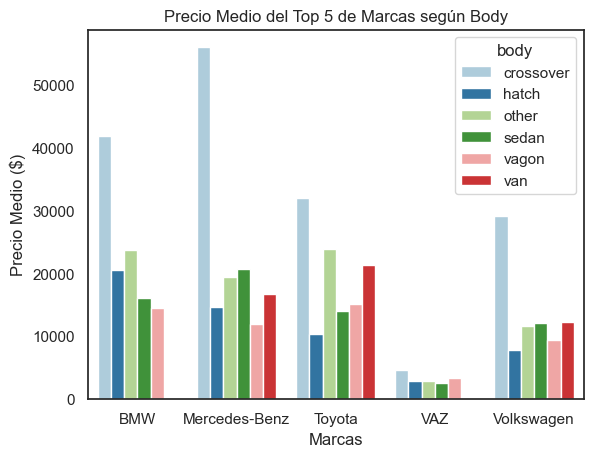

In [84]:
price_top5_body = top5_cars.groupby(["car", "body"])["price"].mean().round(2).reset_index()

sns.barplot(x="car",y="price",hue="body",data=price_top5_body,palette="Paired")
plt.title("Precio Medio del Top 5 de Marcas según Body")
plt.xlabel("Marcas")
plt.ylabel("Precio Medio ($)")
plt.show()


### 10.- Crea un gráfico interactivo que muestre la evolución del precio medio según la edad del coche (Years_Old), separando por Usage_Level.

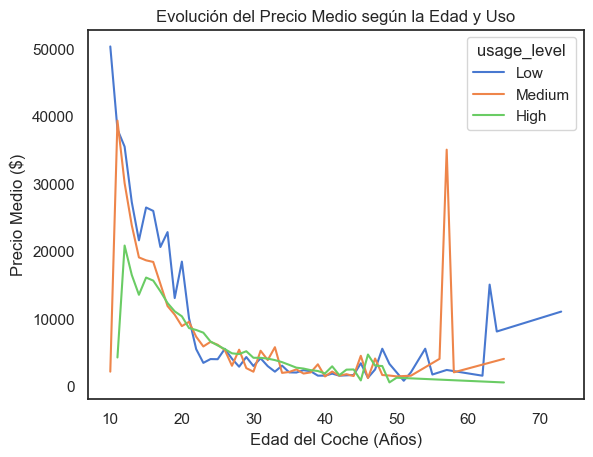

In [ ]:
price_old_usage = df.groupby(["years_old", "usage_level"])["price"].mean().round(2).reset_index()

sns.lineplot(x="years_old", y="price", hue="usage_level", data=price_old_usage, palette="muted")
plt.title("Evolución del Precio Medio según la Edad y Uso")
plt.xlabel("Edad del Coche (Años)")
plt.ylabel("Precio Medio ($)")
plt.show()